We are not coding from scratch but with a well-supported community here:

In [9]:
import sklearn as sk
import pandas as pd



In [10]:
# load the data we are going to process
DATAFILE = 'iris.csv'
iris = pd.read_csv(DATAFILE)

In [11]:
# display the data here to check correctness
iris.head()

,Row,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,1,5.1,3.5,1.4,0.2,setosa
1,2,4.9,3.0,1.4,0.2,setosa
2,3,4.7,3.2,1.3,0.2,setosa
3,4,4.6,3.1,1.5,0.2,setosa
4,5,5.0,3.6,1.4,0.2,setosa


In [12]:
# data manipulation - get rid of the column 'Row'
iris = iris.drop(['Row'], axis=1)

In [13]:
# double check to make sure the above manipulation is correctly executed.
iris.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Let's now split the data into an `X` and `y` and then create a training and test split.

In [14]:
# Make the target numeric, and create training and test sets.
targets = iris['Species'].unique()
target2code = dict(zip(targets, range(len(targets))))

X = iris.iloc[:,:-1] # strip off the row number and target.
y = iris.iloc[:,-1].copy() # don't want to overwrite the original
y = y.apply(lambda x: target2code[x]) # convert each

# Now split these into a training / test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

print('X_train:', X_train.shape)
print('y_train:', y_train.shape)
print('X_test:', X_test.shape)
print('y_test:', y_test.shape)

X_train: (105, 4)
y_train: (105,)
X_test: (45, 4)
y_test: (45,)


# Ensemble classifiers

There are several variants in scikit-learn. You can read about them here: https://scikit-learn.org/stable/modules/ensemble.html

They split into bagged vs boosted ensembles. Let's look at two variants:
* bagged decision trees - or random forests
* boosted decision trees - or AdaBoost

First we're going to use `sklearn.ensemble.RandomForestClassifier` because we want to do classification. We'll mostly just use the default parameters and then `fit` the data to the classifier. However, do look at the web page and have a play around.

Some attributes to pass to the classifier of interest are:
* `n_estimators` is the number of trees to build
* `max_features` controls the number of attributes to select from in each tree
* `oob_score=True` will get the classifier to calculate the out of bag score
* `class_weights` controls how to deal with unbalanced datasets

In [15]:
from sklearn.ensemble import RandomForestClassifier

# Construct a random forest classifier.
clf = RandomForestClassifier(n_estimators = 50, max_features="sqrt", oob_score=True) # changed from auto to sqrt
clf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=50, oob_score=True)

Let's look at the classifier, then look at the prediction for a particular point in the test set.

> Indented block



In [16]:
# We can print the classifier like this.
print(clf)

# The feature impartances can be accessed
print("Feature importances are:", clf.feature_importances_)

# oob score
print("oob score is {:.3f}".format(clf.oob_score_))

# Let's look at one specific prediction.
test_idx = 20
test_point = X_test.iloc[test_idx]

pred_test = clf.predict([test_point])
pred_test_probs = clf.predict_proba([test_point])

print("Testing point", test_idx, "; predicted as", pred_test[0],
      "; actually", y_test.iloc[test_idx], "; probabilities", pred_test_probs[0])

RandomForestClassifier(n_estimators=50, oob_score=True)
Feature importances are: [0.07503993 0.02429283 0.34753089 0.55313635]
oob score is 0.943
Testing point 20 ; predicted as 1 ; actually 1 ; probabilities [0. 1. 0.]


/Users/nicolas/Library/Caches/pypoetry/virtualenvs/data-analytics-uts-kyylW_xd-py3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/nicolas/Library/Caches/pypoetry/virtualenvs/data-analytics-uts-kyylW_xd-py3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


let's make predictions for the test partition, print the
classification report and the confusion matrix.

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.90      1.00      0.95        19
           2       1.00      0.85      0.92        13

    accuracy                           0.96        45
   macro avg       0.97      0.95      0.96        45
weighted avg       0.96      0.96      0.95        45



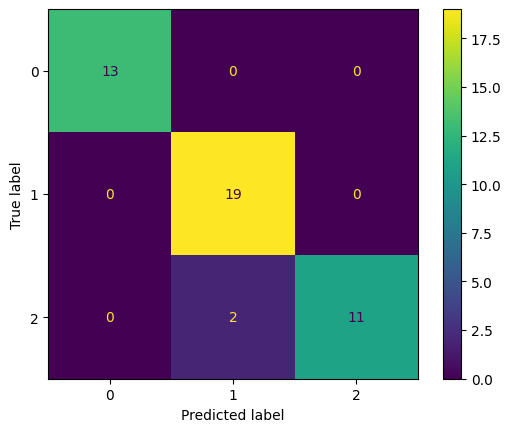

In [17]:
y_pred = clf.predict(X_test)

# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print(classification_report(y_test, y_pred))
conf_max = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(conf_max).plot() # how to explain this confusion matrix is part of the AT3.